In [1]:
# Add module to path
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import pandas as pd
from tqdm import tqdm
from itertools import product
from numba import jit, njit, types
from numba.typed import Dict
import time

# from darts.dartboards import generate_dartboard
from darts.mdp import SinglePlayerContinuousMDP
from darts.stats import expected_score
from darts.utils import mm_per_pixel
from darts.dartboards import DARTBOARD_CONSTANTS

# How to play one player 501

### Triple is funny, but double makes money

The previous blog posts have looked at how a player can improve their game, by choosing where on the board to aim in order to maximise their scores with each individual dart. However, in a real game of [$501$](https://en.wikipedia.org/wiki/Darts#Games), this isn't necessarily the goal of the player; at the start of the game high scores are desirable, but towards the end the player often cares more about preparing to "check out". For those not familiar with $501$:
- The players start with an initial score of $501$, and takes it in turns to throw $3$ darts at a time to lower this score total.
- The winner is the first person to hit a score of exactly $0$ ("checking out").
- If a dart is thrown which scores higher than the player's remaining score, or reaches zero without finishing on a double (the outer ring of the board), then the player is "bust". Their score is put back up to the total they had at the start of their turn, and they forfeit any remaining throws in that turn.

Clearly, when the player has a low score (under 40), they should aim for the relevant double segment (if on an even score), or set up for one on the next throw. There are various [checkout charts](https://dartscheckoutassistant.com/checkout-chart/) that give example checkouts for all possible scores, and these are often memorised by players for use during competitive play.

How can we model the dependence of the players strategy on the current score that they are on? 

### Markov decision process

A natural framework that can be used to model this problem is as a [Markov Decision Process (MDP)](https://en.wikipedia.org/wiki/Markov_decision_process). As the Wikipedia page says, these are useful "for modeling decision making in situations where outcomes are partly random and partly under the control of a decision maker". The components of the Markov Decision Process in this application can be mapped as follows:

| MDP component | Description | Applying to darts |
| -------- | ------- | --- |
| States  | A set of 'states' which represent the different states of the system | Player score states (e.g. $501$ at start of game) |
| Actions | Choices that can be made which transition (potentially probabilistically) to other states. The choice of action will depend on the current state that the player is in. | A choice of point on the dartboard to aim at |
| Transition probabilities    | Probabilities describing the chances of transitioning from one state to another, once a particular action is taken    | Probabilities of hitting certain scores, when the player aims at a particular point on the board. The player's throwing distribution is assumed to be fixed. |
| Rewards | The immediate reward/punishment the player receives when a transition from one state to another is made. | A punishment of -1 is given to the player every time that they throw a dart; the player should seek to minimise the number of darts thrown (and hence the total negative punishment received) |

Simplifying the computations requires reducing the continuous action space of the dartboard. Instead of considering every possible aim point, we can focus on a finite set of points, evenly distributed in two dimensions across the board. Points around the boundaries of scoring regions are also included, accounting for scenarios where a player might aim slightly outside the target — for instance, when going for a double but accounting for potential inaccuracies in aim.

The size of the spacing between the grid of aiming points determines the total number of possible actions in the action space. Smaller spacing brings the analysis closer to the continuous case but also increases the computational cost required to compute the optimal policy. Here is a visualization of the aiming points, representing the action space for the MDP:

In [3]:
board_size = 600 # pixel width
sigma_mm = 40

sigma_pxl = sigma_mm / mm_per_pixel(board_size)

Sigma = sigma_pxl*sigma_pxl*np.array([[1, 0], [0, 1]])
margin = 0.25*sigma_pxl
game_start = 501

In [4]:
mdp = SinglePlayerContinuousMDP(board_size, Sigma, margin, game_start, point_stride=3)

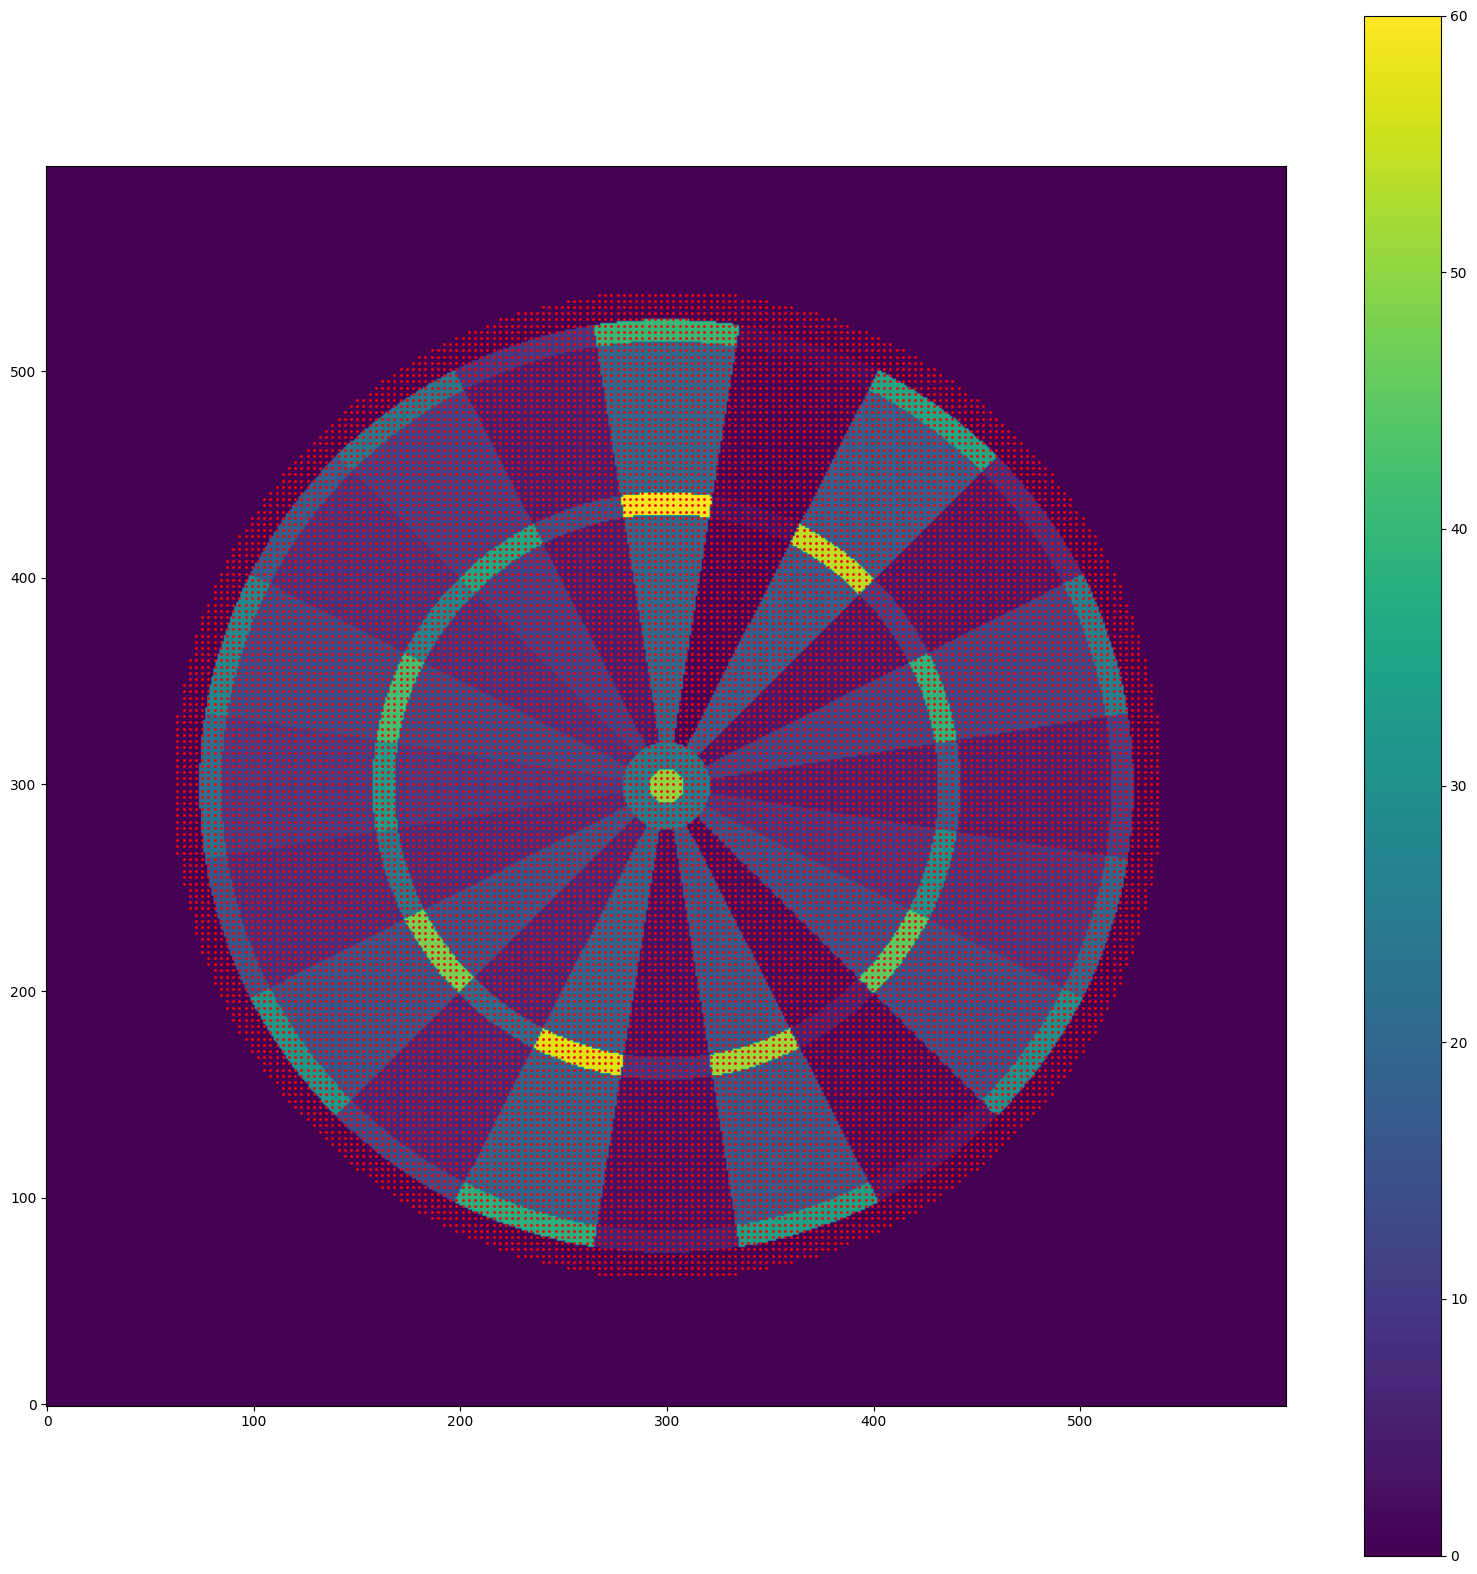

In [5]:
fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(mdp.board, origin='lower')
plt.colorbar()
plt.scatter(mdp.points[:, 0], mdp.points[:, 1], c='r', s=1)

Once the set of actions is defined, it becomes possible to compute the transition probabilities. Using the player’s throwing distribution parameters (discussed in a previous post) and the chosen aiming point, the probabilities of hitting each scoring region are calculated and cached. Assuming the throwing distribution parameters remain constant over time, these cached probabilities can be efficiently retrieved when evaluating the value of each action, avoiding the need for expensive integral computations with every step.

So how can we decide where to aim when in a particular state (i.e. on a specific score)? This challenge lends itself well to a classic reinforcement learning approach known as value iteration. Each state is assigned a value, which, based on our choice of reward function, represents the expected number of turns required to check out from that state. For each action, the expected value of the resulting state is computed, accounting for the probabilities of different outcomes. The action that maximizes the reward — reducing the expected number of remaining turns the most — is the one selected.

For each state, the state-value function $v(s)$ satisfies the optimal Bellman equation:
$$
v(s) = -1 + \max_{a\in\mathcal{A}}\left(\sum_{t\in\Omega}u_a(s, t)\right),
$$
$$
\begin{equation}
u_a(s, t) =
\begin{cases}
p^{a}_t v(s-t), & \text{if } s-t>1, \\
(p^{a}_t - dp^{a}_t)v(s), & \text{if } s = t, \\
p^{a}_t v(s), & \text{otherwise}
\end{cases}
\end{equation}
$$
The definitions of the various variables in this expression are as follows:
- $p^{a}_{t}$ is the probability of hitting a region with score $t$ when aiming at point $a$,
- $dp^{a}_{t}$ is the probability of hitting a double region of score $t$ when aiming at point $a$,
- $\Omega$ is the sample space of all possible dart scores,
- $\mathcal{A}$ is the set of all possible actions.
   
This equation essentially says that the value of a state is given by the maximum expected value of all other reachable states, taking into account the cost of taking an additional throw. Although the expression for $u_a(s, t)$ looks convoluted, it captures the three main outcomes of a dart throw: scoring less than the player’s current score (a valid throw), scoring exactly the current player score (only legal if the region is a double), or exceeding the player’s score (resulting in a bust, where the score reverts to its previous value). The expression also accounts for the possibility of leaving the player with a score of exactly 1, which is treated the same as a bust. This is because a player must finish on a double score to check out legitimately, making a score of 1 an invalid outcome.


Here’s a high-level overview of how state values are computed, taking advantage of the structure of the problem to avoid unnecessary computations:

Inputs:

- __Player’s throwing distribution__: Defined by the covariance matrix $\Sigma$.
- __Action stride__: The step size for the grid - how many pixels to skip in each direction before adding a new point to the action space.
- __Starting state__: Typically, the game begins at 501. However, as we’ll see, the specific starting state has a limited impact on the overall method.

Method:
1. Create the set of possible actions, and compute the transition probabilities under each action. Cache these values for later use
2. Loop over states, starting from the smallest non-trivial state (with a score of 2) and working up to the largest. The value of the state __0__ is defined to be exactly 0 - i.e. $v(0) = 0$.
3. For each state, compute the right hand side of the Bellman equation. As it is only possible to decrease your score with each throw (or keep it the same), this only involves state values up to and including the current value. Repeat this until convergence (within some specified tolerance).
4. Once the value function has converged for all state values, compute the optimal policy by finding the action from each starting state which maximises the expected state value after taking the action (hint: use an $argmax$ instead of a $max$ in the right hand side of the optimal Bellman equation).

This method is efficient because it allows computation one state at a time, taking advantage of the assumption that the values of smaller states have already converged. At the end, we are left with a mapping from state (starting score) to optimal action (place to aim on the board which minimises the expected number of throws remaining).

To demonstrate this, let's choose a covariance matrix for an example player of:

$$
\begin{equation}
\Sigma = \sigma^2
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix}.
\end{equation}
$$

where we choose the variance parameter $\sigma=40$mm. Then, we can follow the above algorithm to find the value function for each starting score:

In [6]:
mdp.compute_values(threshold=0.0001)

C:\Users\mikey\anaconda3\envs\darts\Lib\site-packages\numba\typed\typeddict.py:34: NumbaTypeSafetyWarning: unsafe cast from int64 to int32. Precision may be lost.
  d[key] = value
100%|██████████| 502/502 [02:45<00:00,  3.04it/s]
C:\Users\mikey\OneDrive\Documents\PycharmProjects\Darts\darts\mdp.py:108: NumbaTypeSafetyWarning: unsafe cast from none to array(int32, 1d, A). Precision may be lost.
  policy[state] = max_a


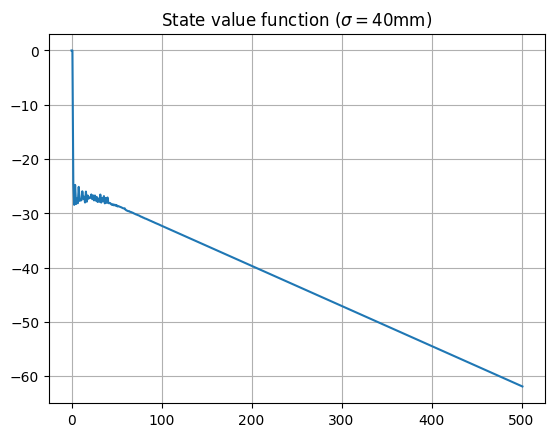

In [89]:
plt.plot(mdp.values.values())
plt.title('State value function ($\sigma=40$mm)')
plt.grid()

Some initial observations from this plot are:
- For a score of above around $50$, the state values are approximately linear. For large enough player scores, given the player's ability, they are looking to maximise the expected score on each dart, so are aiming for roughly the same place on the board each time.
- For a score of below around $50$, the start values oscillate around a value of about $-27$, corresponding to an expected number of $27$ turns until checkout. Clearly, this player has trouble hitting a double to check out, so takes the about the same number of throws regardless. There is a difference between odd and even states, due to the player needing to finish on an even score, which can be seen by zooming in on this region:

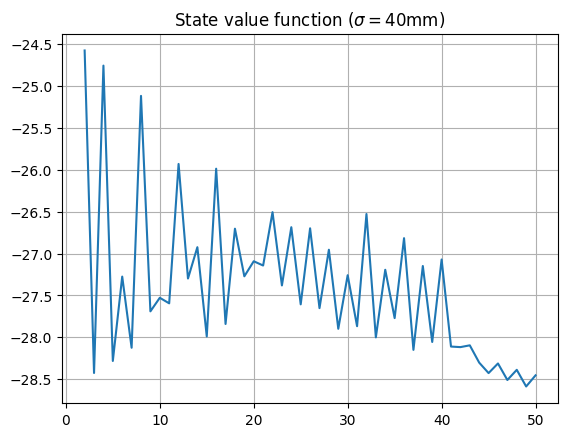

In [88]:
plt.plot(list(mdp.values.keys())[2:51], list(mdp.values.values())[2:51])
plt.title('State value function ($\sigma=40$mm)')
plt.grid()

With the optimal policy for this player in hand, we can visualize the ideal aiming point on the dartboard for each starting score (here plotted for scores less than 70):

In [9]:
df = pd.DataFrame([(state, mdp.board[*point], point) for state, point in mdp.policy.items()], 
                  columns=['state', 'target', 'point']).set_index('state')
df.to_csv('results/std40mm.csv')

In [10]:
cmap = plt.cm.autumn
norm = colors.Normalize(vmin=0, vmax=100)

In [76]:
def plot_policy(mdp, lower_limit, upper_limit, title):
    fig, ax = plt.subplots(figsize=(15, 15))
    for s, point in mdp.policy.items():
        if lower_limit <= s <= upper_limit:
            #ax.scatter(*point[::-1], c=cmap(norm(s)))
            ax.annotate(s, [point[1], point[0]], c='red', ha='center', va='center')
    ax.matshow(mdp.board, origin='lower')
    ax.set_xlim(50, 550)
    ax.set_ylim(50, 550)
    ax.axis('off')
    ax.set_title(title)

    for score, angles in DARTBOARD_CONSTANTS['SEGMENTS'].items():
        if score == 11:
            angle = -np.pi
        else:
            angle = 0.5*(angles[0][0] + angles[0][1])*np.pi

        r = board_size*0.5*0.6
        x = r*np.cos(angle)
        y = r*np.sin(angle)
        ax.annotate(score, [board_size//2 + x, board_size//2 + y], c='yellow', ha='center', va='center', fontsize=25)

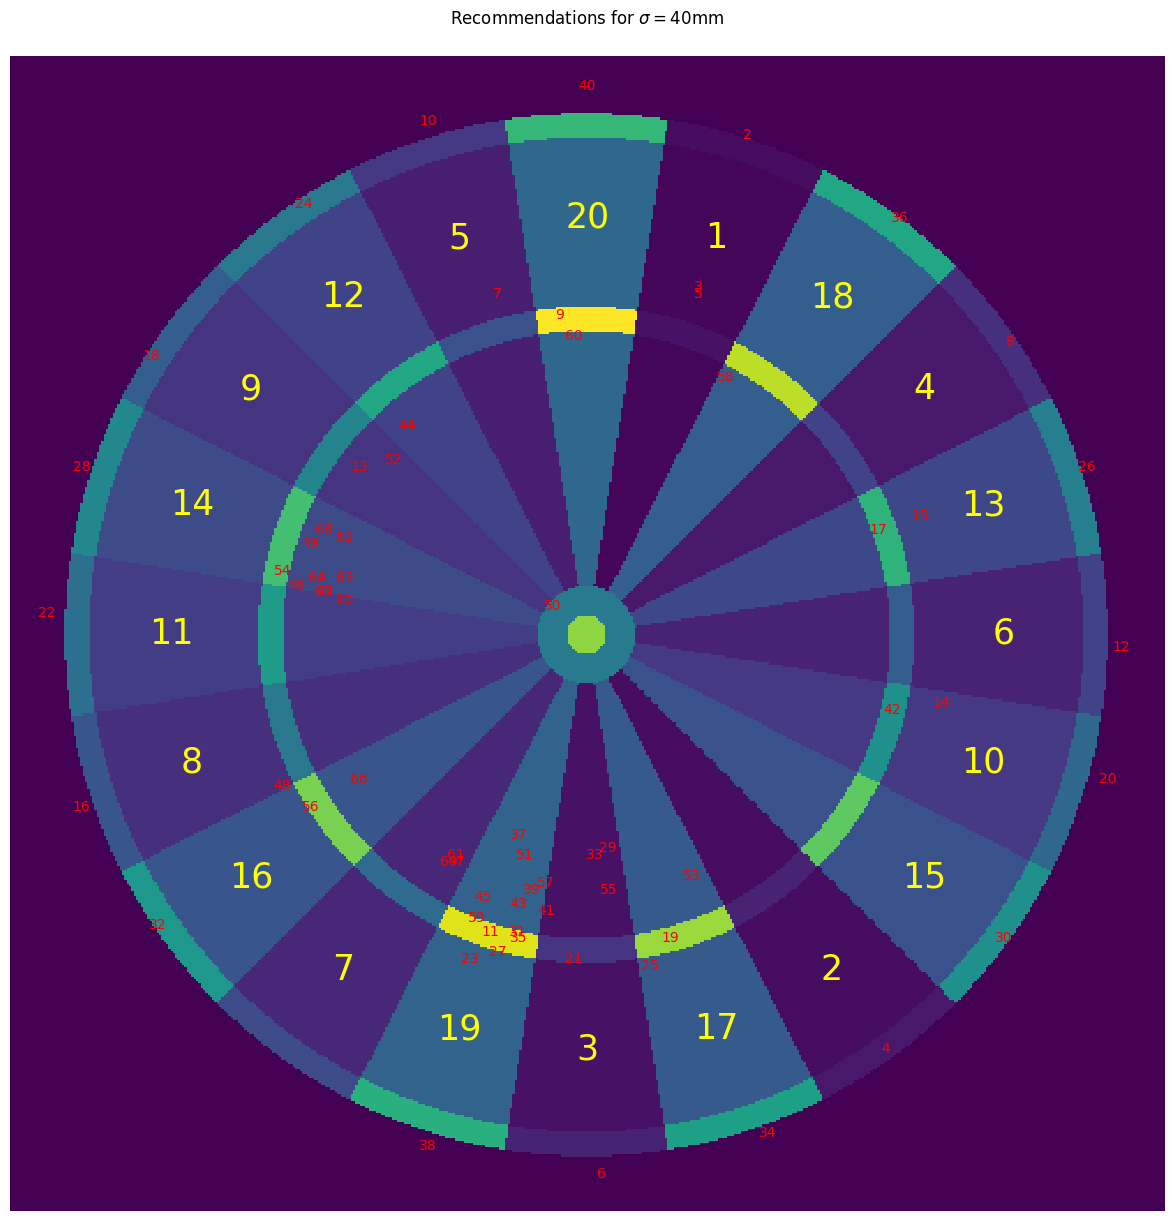

In [78]:
plot_policy(mdp, 2, 70, 'Recommendations for $\sigma=40$mm')

This diagram reveals some strategies that any keen darts player might recognize:

- Even numbers below 40: Aim for the double region corresponding to the score for an instant win. For this player, with a spherically symmetric throwing distribution, the optimal target is just outside the double. This increases the chances of missing into a 0 rather than hitting a non-zero (and potentially odd) score.
- Low odd scores: The strategy is to aim for a region that leaves an even number, ideally a power of 2. For instance, a player on 5 aims for 1 (5-1=4), a player on 25 aims for 17 (25-17=8), and a player on 44 aims for 12 (44-12=32).
- Score of 50: The optimal target is near the bullseye, which is also a legitimate checkout.
- Higher scores: The advice shifts to aiming near the treble 19, which maximizes the expected score with a single throw (as a previous post has shown).

Let's repeat the analysis for a different player, with a slightly better throwing ability - this time with a variance parameter of $\sigma=10$mm:

In [15]:
better_sigma_mm = 10
better_sigma_pxl = better_sigma_mm / mm_per_pixel(board_size)

better_Sigma = better_sigma_pxl*better_sigma_pxl*np.array([[1, 0], [0, 1]])

margin = 0.25*sigma_pxl
game_start = 501
better_mdp = SinglePlayerContinuousMDP(board_size, better_Sigma, margin, game_start, point_stride=3)

In [16]:
better_mdp.compute_values(threshold=0.0001)

100%|██████████| 502/502 [01:06<00:00,  7.57it/s]


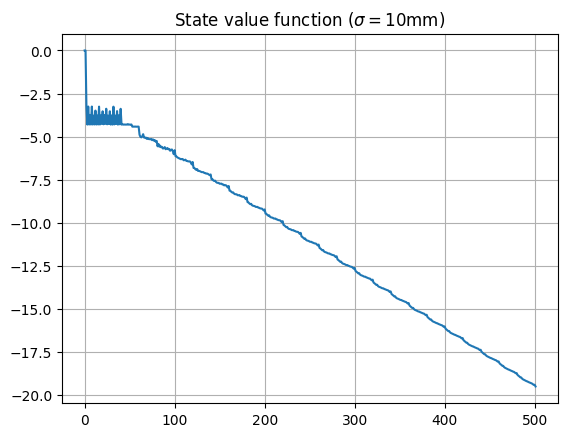

In [82]:
plt.plot(better_mdp.values.values())
plt.title('State value function ($\sigma=10$mm)')
plt.grid()

We see that the linearity breaks down slightly for larger state values, implying that the player is not simply trying to maximise 1-dart score, but will take a more sophisticated approach (as we'll see). Zooming in on the region of low state scores:

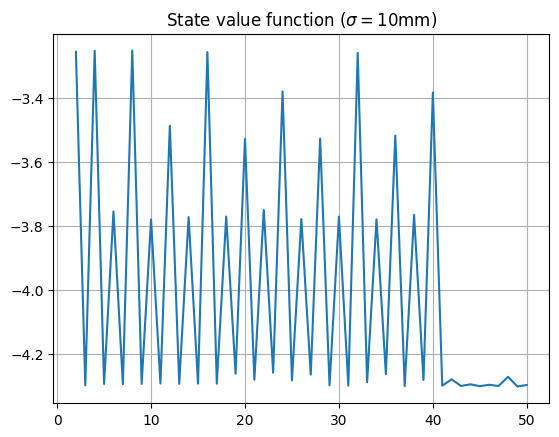

In [83]:
plt.plot(list(better_mdp.values.keys())[2:51], list(better_mdp.values.values())[2:51])
plt.title('State value function ($\sigma=10$mm)')
plt.grid()

Note that states that are a power of two are all approximately equally valued, with states that are multiples of 8 and 4 coming close behind; even states are more valuable than odd states; and state values drop above the maximum 1-dart checkout score of 40. Let's see what is recommended for this player on the dartboard:

In [19]:
better_df = pd.DataFrame([(state, better_mdp.board[*point], point) for state, point in better_mdp.policy.items()], 
                  columns=['state', 'target', 'point']).set_index('state')
better_df.to_csv('results/std10mm.csv')

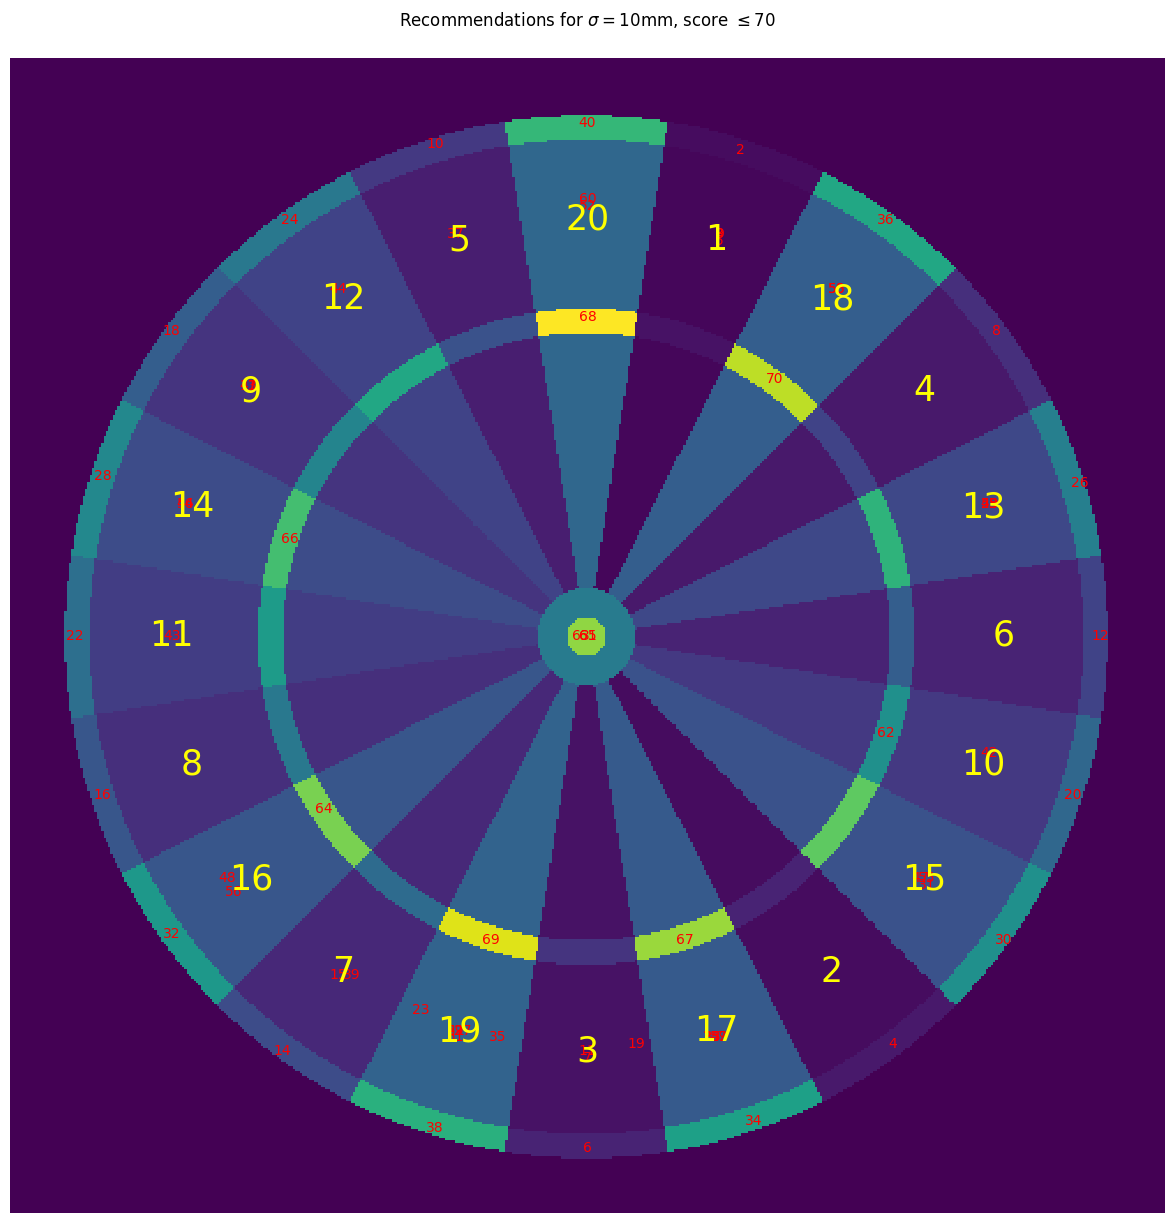

In [86]:
plot_policy(better_mdp, 2, 70, 'Recommendations for $\sigma=10$mm, score $\leq 70$')

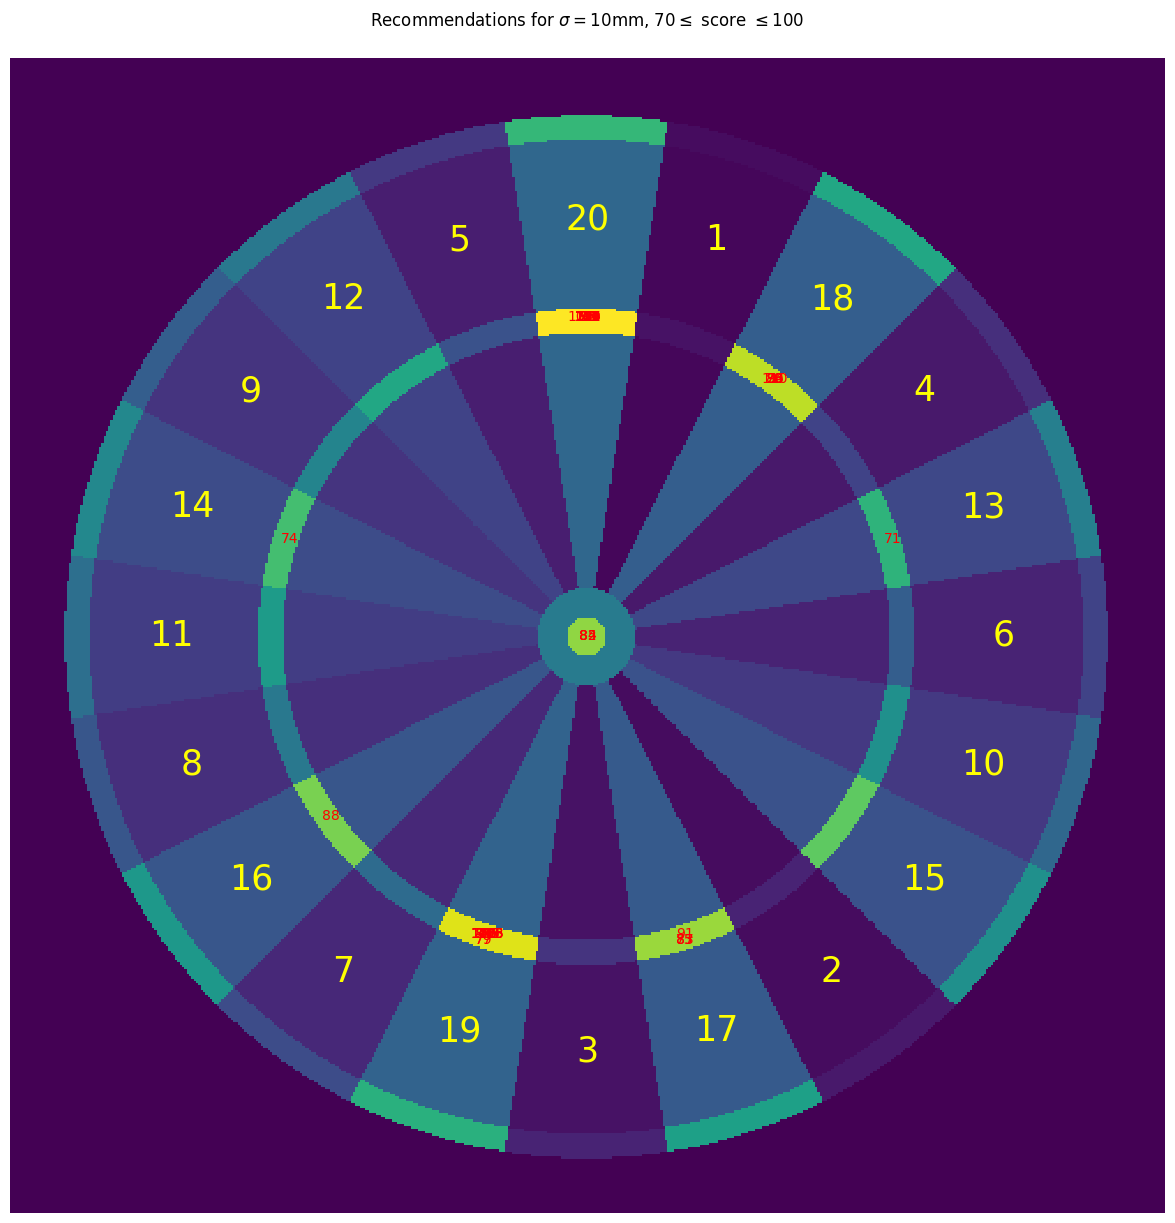

In [87]:
plot_policy(better_mdp, 70, 120, 'Recommendations for $\sigma=10$mm, $70\leq$ score $\leq 100$')

For this more skilled player:
- Checkout aiming points are closer to the centres of the double regions, rather than being positioned outside of them
- We still see recommendations that reduce the score to a power of 2; however, these recommendations now take advantage of the increased skill of the player by recommending triples (when on 62, aim for triple 10 to drop down to 32) and bullseyes (when on 66, aim for bullseye to drop to 16)
- There is less of an emphasis on getting a high 1-dart score, as evidenced by the reduction in the clustering around the triple 19; instead, the player is recommended to aim for specific scores which will set them up well for a checkout.

### Quadro

This analysis can be repeated for the Quadro board, which now includes the inticing quadruple-score regions (see this post for background). Here are the aiming points in the action space, covering the board and the region around it:

In [22]:
mdp_quadro = SinglePlayerContinuousMDP(board_size, Sigma, margin, game_start, quadro=True, point_stride=3)

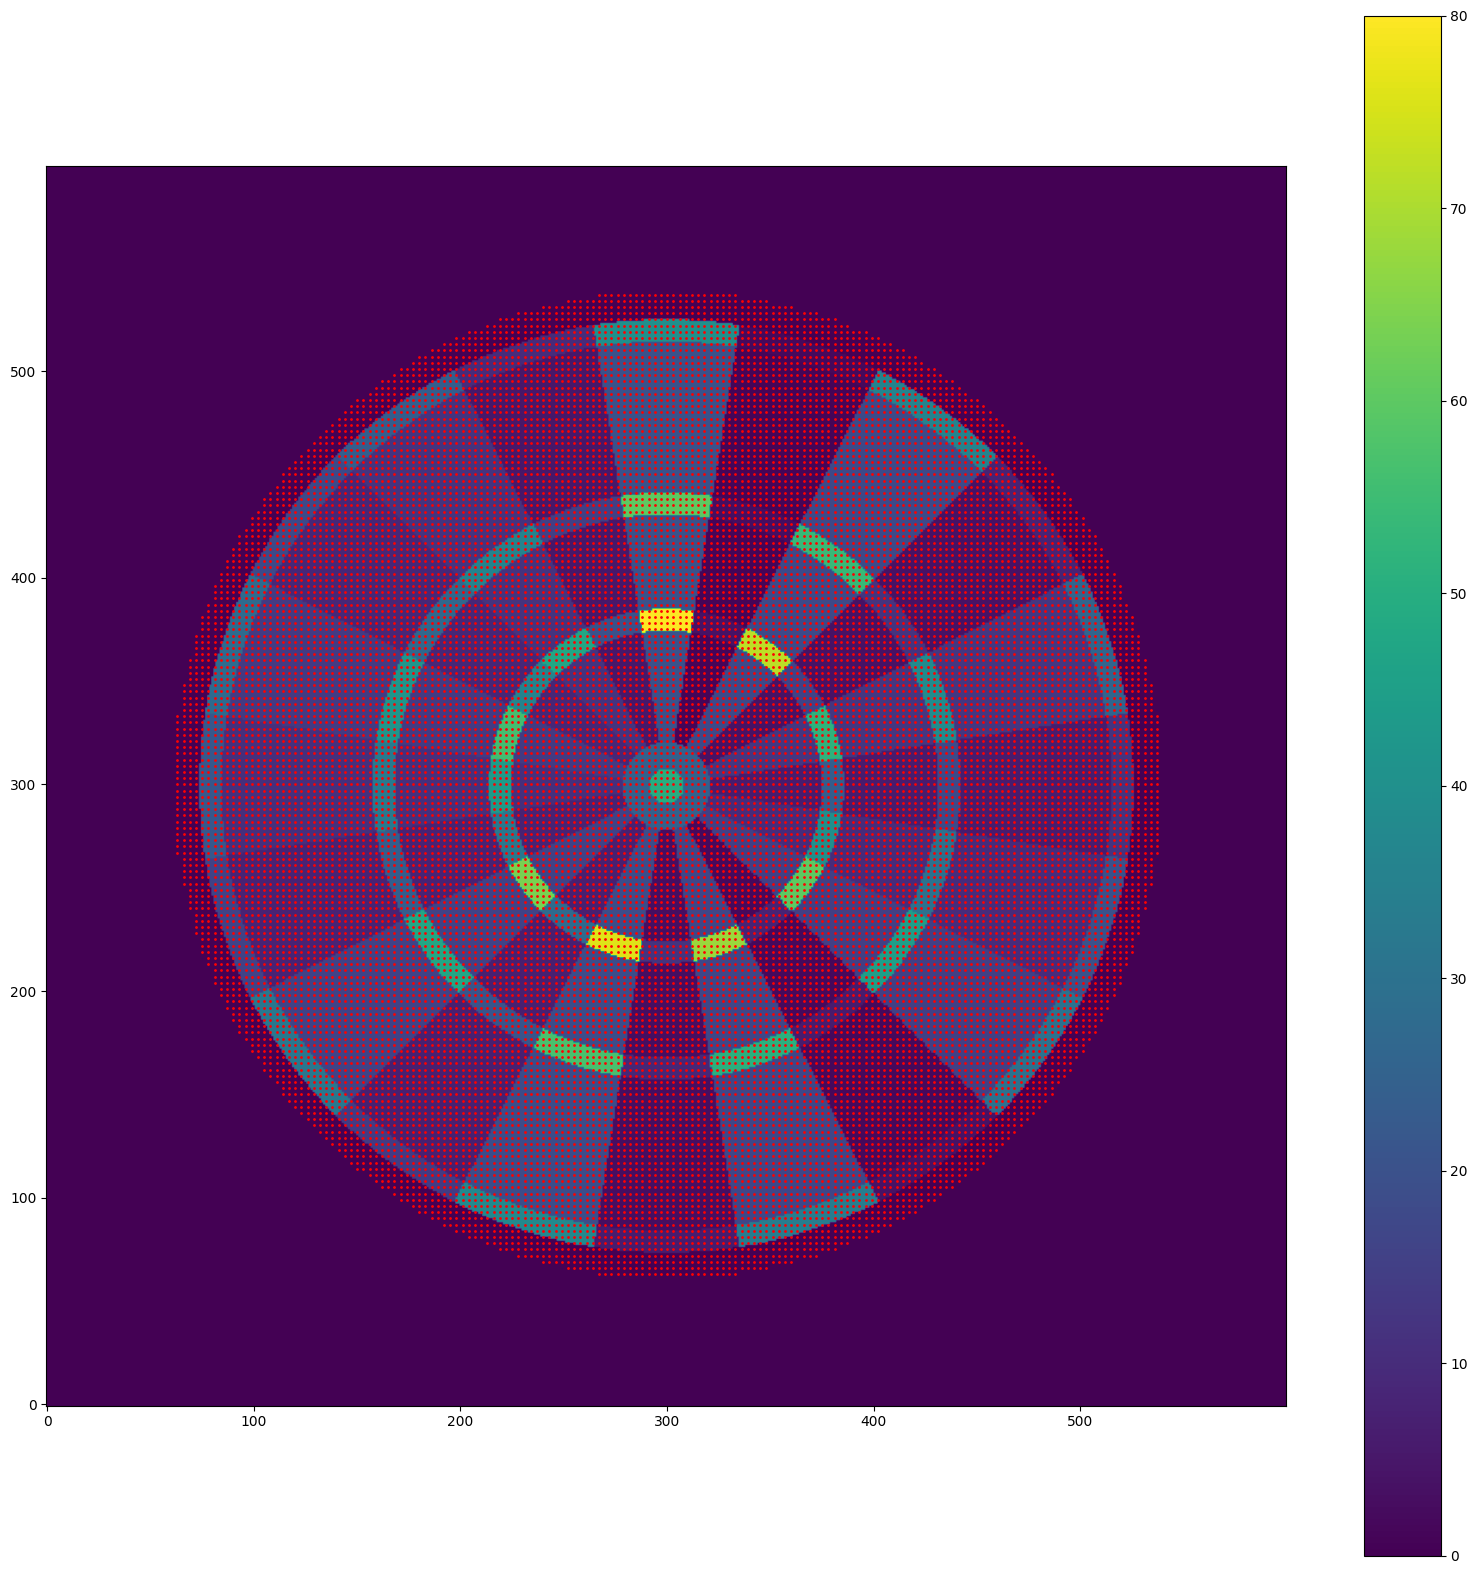

In [23]:
fig, ax = plt.subplots(figsize=(20, 20))
plt.imshow(mdp_quadro.board, origin='lower')
plt.colorbar()
plt.scatter(mdp_quadro.points[:, 0], mdp_quadro.points[:, 1], c='r', s=1)

In [24]:
mdp_quadro.compute_values(threshold=0.001)

100%|██████████| 502/502 [01:42<00:00,  4.90it/s]


And for our first, unskilled player ($\sigma=40$mm), here is the plot of the state values found by the same optimal Bellman value iteration algorithm, along with the state function found for the standard dartboard: 

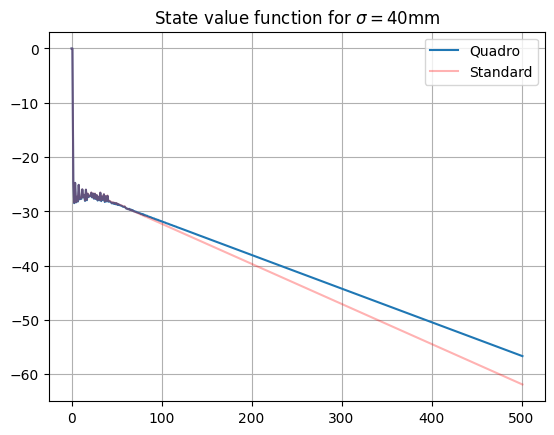

In [51]:
plt.plot(mdp_quadro.values.values(), label='Quadro')
plt.plot(mdp.values.values(), color='r', alpha=0.3, label='Standard')
plt.title('State value function for $\sigma=40$mm')
plt.legend()
plt.grid()

We see that the values are close for small states values, but diverge as the states increase; this is further confirmed by zooming in on small-score section of the graph, showing very small differences between the two value functions: 

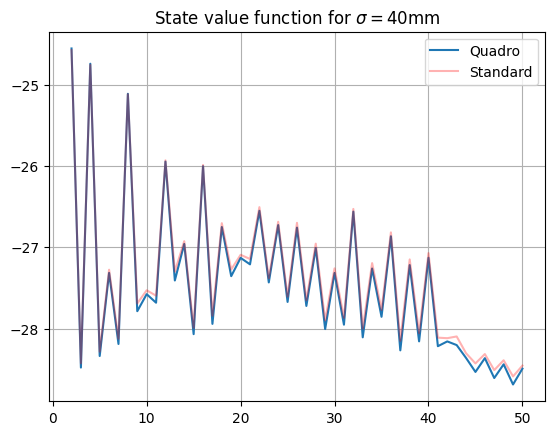

In [54]:
plt.plot(list(mdp_quadro.values.keys())[2:51], list(mdp_quadro.values.values())[2:51], label='Quadro')
plt.plot(list(mdp.values.keys())[2:51], list(mdp.values.values())[2:51], color='r', alpha=0.3, label='Standard')
plt.title('State value function for $\sigma=40$mm')
plt.legend()
plt.grid()

So for small scores, the strategy of the unskilled player is approximately the same on either dartboard; for large scores (i.e. near the start of the game), the player is clearly making use of the quadruple scoring regions to get higher average 1-dart scores. Let's take a look at the players recommendations on the dartboard itself:

In [27]:
quadro_df = pd.DataFrame([(state, mdp_quadro.board[*point], point) for state, point in mdp_quadro.policy.items()], 
                  columns=['state', 'target', 'point']).set_index('state')
quadro_df.to_csv('results/std40mm_quadro.csv')

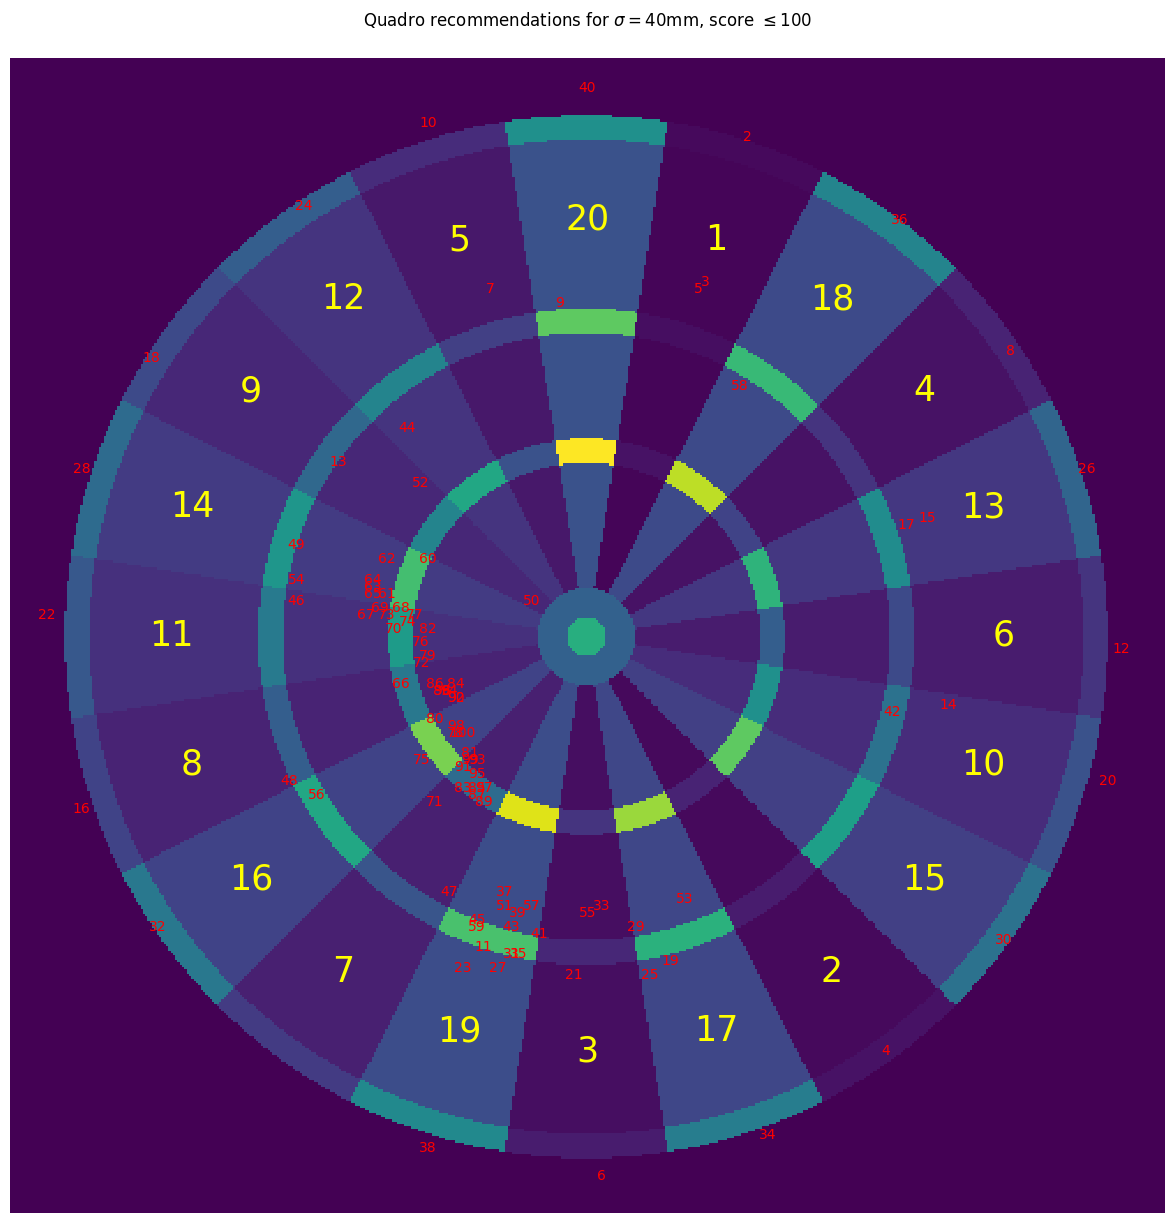

In [96]:
plot_policy(mdp_quadro, 2, 100,'Quadro recommendations for $\sigma=40$mm, score $\leq 100$')

There is a cluster around the triple 19 as before, but for larger scores the recommendations are in the quadruple scoring regions on the left hand side of the board - this is consistent with the findings of this previous post investigating the maximising of 1-dart scores.

Finally, let's repeat this for the skilled player to see how the value function differs for the quadro board:

In [30]:
better_mdp_quadro = SinglePlayerContinuousMDP(board_size, better_Sigma, margin, game_start, quadro=True, point_stride=3)

In [31]:
better_mdp_quadro.compute_values(threshold=0.0001)

100%|██████████| 502/502 [01:13<00:00,  6.82it/s]


In [32]:
better_quadro_df = pd.DataFrame([(state, better_mdp_quadro.board[*point], point) for state, point in better_mdp_quadro.policy.items()], 
                  columns=['state', 'target', 'point']).set_index('state')
better_quadro_df.to_csv('results/std10mm_quadro.csv')

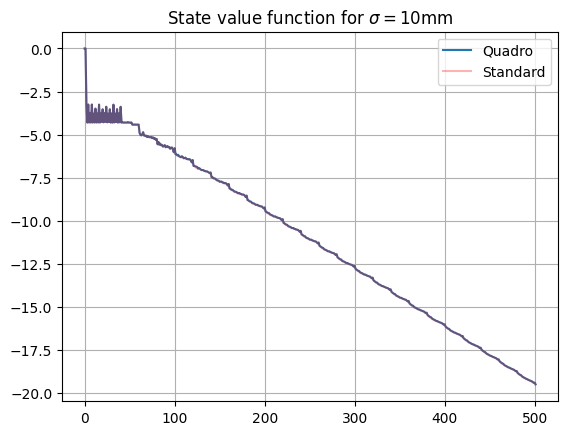

In [92]:
plt.plot(better_mdp_quadro.values.values(), label='Quadro')
plt.plot(better_mdp.values.values(), color='r', alpha=0.3, label='Standard')
plt.title('State value function for $\sigma=10$mm')
plt.legend()
plt.grid()

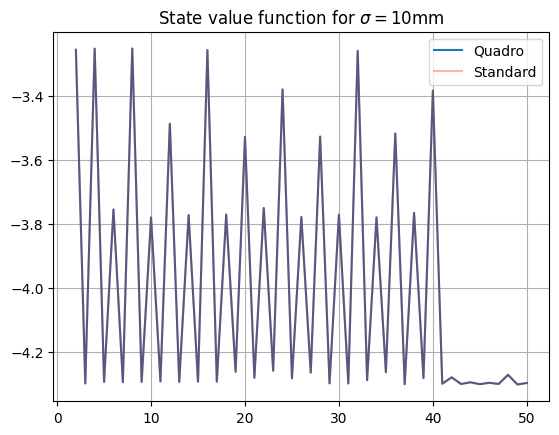

In [55]:
plt.plot(list(better_mdp_quadro.values.keys())[2:51], list(better_mdp_quadro.values.values())[2:51], label='Quadro')
plt.plot(list(better_mdp.values.keys())[2:51], list(better_mdp.values.values())[2:51], color='r', alpha=0.3, label='Standard')
plt.title('State value function for $\sigma=10$mm')
plt.legend()
plt.grid()

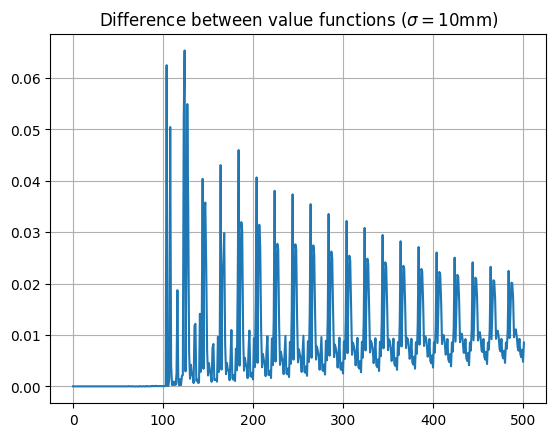

In [94]:
plt.plot(np.array(list(better_mdp_quadro.values.values())) - np.array(list(better_mdp.values.values())))
plt.title('Difference between value functions ($\sigma=10$mm)')
plt.grid()

As the value functions are identical for states less than 100, the strategies are identical here (so the quadruple regions are irrelevant!). For higher values, there are small differences in state values, which do lead to some differences in strategy (mainly for scores slightly above 100). This can be seen on the recommendation diagram:

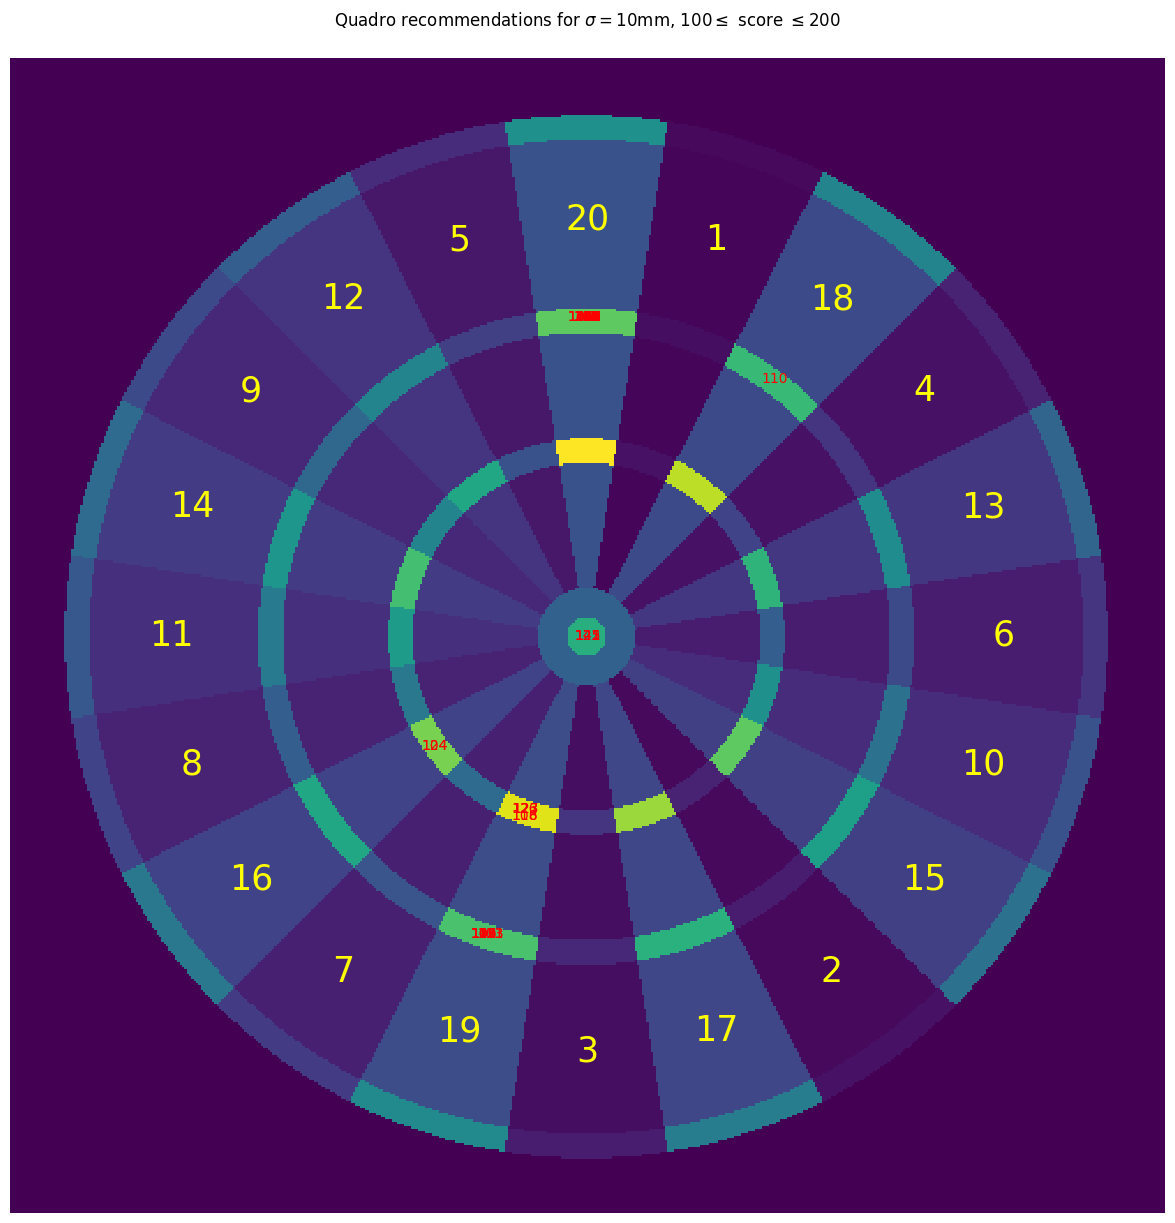

In [103]:
plot_policy(better_mdp_quadro, 100, 200, 'Quadro recommendations for $\sigma=10$mm, $100 \leq$ score $\leq 200$')

A similar plot (not displayed here) shows that for scores above 200, all recommended aim points are in the triple 20 region. So even for this skilled player, the quadruple regions are only relevant for a small set of specific scores just above 100; for all other scores, the strategy of the player is identical to the strategy on a standard dartboard.